# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script 

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

In [3]:
# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

In [4]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script 

In [6]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [7]:
y_pred = model.predict(X_test)

In [8]:
print(y_pred)

[84.61206897 55.88793103]


In [9]:
y_pred = model.predict(X_test)

In [10]:
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [11]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The actual data points follow the regression line very closely. As the number of hours studied increases, the exam score also tends to increase. The small distance between the data points and the regression line suggests that the model fits the data well and is able to make accurate predictions.

The actual data points generally follow the regression line closely, showing a clear positive relationship between hours studied and exam score. While not every point falls exactly on the line, most are near it, which suggests the model does a good job of capturing the overall trend in the data. 

## Lab 2
### Building your own model

In [14]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000,
                         9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                        12400, 13100, 14200, 15600, 15900, 17200, 18100,
                        19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [15]:
# Feature matrix (must be 2D DataFrame)
X2 = df_ads[['monthly_ad_spend']]

# Target vector (1D Series)
y2 = df_ads['monthly_revenue']

In [16]:
# Print shapes
print("Shape of X2:", X2.shape)
print("Shape of y2:", y2.shape)

Shape of X2: (20, 1)
Shape of y2: (20,)


In [17]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [18]:
print("Training set size (X2_train):", X2_train.shape)
print("Test set size (X2_test):", X2_test.shape)
print("Training set size (y2_train):", y2_train.shape)
print("Test set size (y2_test):", y2_test.shape)

Training set size (X2_train): (16, 1)
Test set size (X2_test): (4, 1)
Training set size (y2_train): (16,)
Test set size (y2_test): (4,)


In [19]:
# Create the model
model2 = LinearRegression()

# Fit the model to training data
model2.fit(X2_train, y2_train)

# Confirmation message
print("Model trained successfully.")

Model trained successfully.


In [20]:
# Print model parameters
print(f"Slope (coefficient): {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope (coefficient): 1.96
Intercept: 3625.89


In [21]:
# Interpretation:
# For each additional $1,000 spent on advertising, monthly revenue increases by about (model2.coef_[0] * 1000)

### Making predictions and evaluating the model

In [22]:
# Make predictions on the test set
y2_pred = model2.predict(X2_test)

# Print actual vs predicted values side by side
print("Actual Revenue vs Predicted Revenue:\n")

Actual Revenue vs Predicted Revenue:



In [23]:
for actual, predicted in zip(y2_test, y2_pred):
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f}")

Actual: 4200.00 | Predicted: 4603.85
Actual: 21500.00 | Predicted: 21229.03
Actual: 19400.00 | Predicted: 19273.13
Actual: 5100.00 | Predicted: 5581.80


In [24]:
r2 = model2.score(X2_test, y2_test)
print(f"R² score: {r2:.3f}")

R² score: 0.998


### Visualizing the results

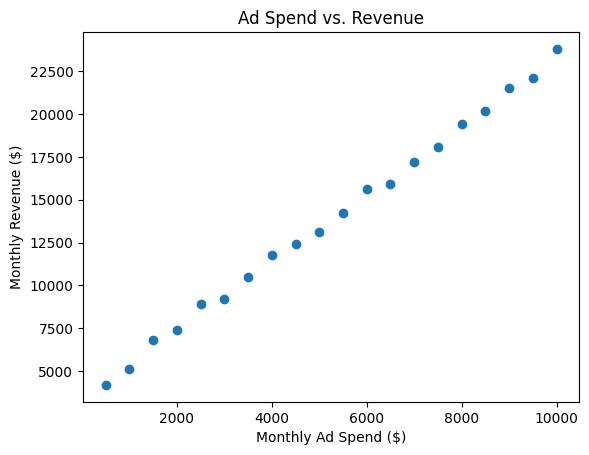

In [25]:
# Scatter plot of full dataset (no regression line)
plt.scatter(X2, y2)

# Labels and title
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

# Show plot
plt.show()

C:\Users\alondramartinez\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


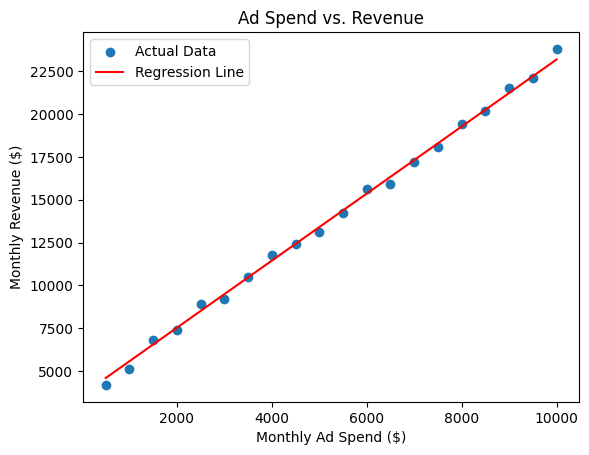

In [26]:
# Scatter plot of full dataset
plt.scatter(X2, y2, label='Actual Data')

# Create regression line values
x_range = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
y_line = model2.predict(x_range)

# Plot regression line
plt.plot(x_range, y_line, color='red', label='Regression Line')

# Labels and title
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

# Legend
plt.legend()

# Show plot
plt.show()

Looking at the graph, the regression line seems to fit the data pretty well. Most of the points are close to the line, and there’s a clear upward trend between ad spend and revenue. This matches what the R² score showed earlier since it was high, meaning the model explains most of the variation in the data. Overall, the results from both the plot and the R² score make sense together and show that the model is doing a good job.